# Part 3: Advanced Text Processing - LDA and BERTopic Topic Modeling

### Read Data

In [8]:
# imports
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8-dark')

In [2]:
# To save our figures
from pathlib import Path
outputs_dir = Path('outputs')

In [3]:
sou = pd.read_csv("data/SOTU.csv")

In [5]:
import spacy
from tqdm import tqdm
from collections import Counter

nlp = spacy.load("en_core_web_sm")

In [9]:
from spacy import displacy
from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis
import pyLDAvis.gensim_models

### LDA Model

In [10]:
def preprocess_text(text): 
    doc = nlp(text) 
    return [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 3]

In [11]:
# Process all texts - note this takes ~ 5 minutes to run
processed_docs = sou['Text'].apply(preprocess_text)

In [12]:
processed_docs.head()

0    [speak, president, present, prepared, remark, ...
1    [president, speaker, point, president, turn, f...
2    [president, thank, thank, thank, madam, speake...
3    [president, thank, thank, thank, good, mitch, ...
4    [president, thank, thank, thank, madam, speake...
Name: Text, dtype: object

In [13]:
# A dictionary from processed_docs, which is a list of tokens extracted from our speeches
texts_tokens = processed_docs.tolist()
dictionary = Dictionary(texts_tokens)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]

#### Trained LDA model with 18 topics

In [14]:
# train LDA model with 18 topics
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=18,
    random_state=42,
    passes=10
)

#### Top 10 words for each topic

In [15]:
# print the top 10 words for each topic
for idx, topic in lda_model.print_topics(num_topics=18, num_words=10):
    print(f"Topic {idx}:\n{topic}\n")

Topic 0:
0.008*"canal" + 0.005*"tariff" + 0.004*"panama" + 0.004*"statute" + 0.004*"company" + 0.004*"method" + 0.004*"convention" + 0.003*"board" + 0.003*"cent" + 0.003*"china"

Topic 1:
0.003*"mexico" + 0.001*"texas" + 0.001*"mexican" + 0.001*"convention" + 0.001*"americans" + 0.001*"minister" + 0.001*"program" + 0.001*"article" + 0.001*"cent" + 0.001*"loan"

Topic 2:
0.006*"method" + 0.005*"board" + 0.005*"agricultural" + 0.005*"farmer" + 0.005*"cent" + 0.004*"farm" + 0.004*"project" + 0.004*"veteran" + 0.004*"depression" + 0.004*"committee"

Topic 3:
0.004*"cent" + 0.004*"gold" + 0.004*"silver" + 0.003*"indian" + 0.003*"june" + 0.003*"bond" + 0.003*"method" + 0.003*"island" + 0.002*"conference" + 0.002*"tariff"

Topic 4:
0.019*"spain" + 0.009*"article" + 0.007*"minister" + 0.006*"likewise" + 0.005*"manufacture" + 0.005*"port" + 0.005*"tribe" + 0.005*"intercourse" + 0.004*"presume" + 0.004*"colony"

Topic 5:
0.009*"tariff" + 0.008*"corporation" + 0.007*"evil" + 0.006*"cable" + 0.005

#### Topic distribution for the first speech

In [16]:
first_speech_bow = corpus[0]
lda_model.get_document_topics(first_speech_bow)

[(7, 0.99942523)]

#### pyLDAvis Visualization

In [17]:
# make a visualization using pyLDAvis
pyLDAvis.enable_notebook()
lda_vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
pyLDAvis.save_html(lda_vis, "outputs/lda_topics.html")
lda_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
16     0.124684 -0.016058       1        1  23.653270
3      0.047043  0.069631       2        1  22.185260
7     -0.249568 -0.032435       3        1  16.493457
15    -0.148444  0.093409       4        1  12.986515
0      0.042368  0.115060       5        1   6.481636
12     0.140061 -0.005773       6        1   6.076826
2     -0.028744  0.157597       7        1   3.946856
14     0.115200  0.048899       8        1   2.810700
10     0.072309  0.026057       9        1   2.146034
4      0.168740 -0.086130      10        1   1.301751
6     -0.162808 -0.128171      11        1   0.610865
5     -0.012308  0.061678      12        1   0.486877
9     -0.084382  0.041350      13        1   0.414912
17     0.051993 -0.138049      14        1   0.284721
13     0.022478 -0.077904      15        1   0.108571
1     -0.025788 -0.039226      16        1   0.003917
8     -0.027274 -0.044925      17        1   0.003917
11    -0.045561 -0.045010      18        1   0.003917, topic_info=           Term         Freq        Total Category  logprob  loglift
31    americans   983.000000   983.000000  Default  30.0000  30.0000
509     program  1305.000000  1305.000000  Default  29.0000  29.0000
665     tonight   654.000000   654.000000  Default  28.0000  28.0000
976      mexico   820.000000   820.000000  Default  27.0000  27.0000
656       thank   374.000000   374.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
1653       area     0.006954   441.132280  Topic18  -7.5829  -0.9101
737      worker     0.006925   457.662538  Topic18  -7.5871  -0.9510
3016    surplus     0.006855   448.039428  Topic18  -7.5973  -0.9400
407    minister     0.006909   556.388247  Topic18  -7.5894  -1.1487
2169     island     0.006898   582.748338  Topic18  -7.5910  -1.1966

[1340 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
5548      4  0.188485   -the
5548      6  0.188485   -the
5548      8  0.376969   -the
5548     13  0.188485   -the
7117      1  0.908864   1794
...     ...       ...    ...
742       9  0.026307  young
742      11  0.016442  young
742      12  0.006577  young
742      13  0.003288  young
6556      2  0.910626  yukon

[5421 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[17, 4, 8, 16, 1, 13, 3, 15, 11, 5, 7, 6, 10, 18, 14, 2, 9, 12])

### BERTopic

- Train a BERTopic model with a `min_topic_size` of 3 *Hint: use `BERTopic` to instantiate the model and specify `min_topic_size` in here. Actually fit the model using `fit_transform`, which `docs` passed into this.*
- Output the top 10 words for each topic. 
- Output the topic distribution for the first speech
- Make a visualization of the topics (see topic_model.visualize_topics())

In [18]:
docs = sou['Text'].to_list()

#### Trained BERTopic model

Here we trained a BERTopic model with a `min_topic_size` of 3 and vectorizer to remove stop words.

In [19]:
# train the model - this takes about 30 seconds
vectorizer = CountVectorizer(stop_words="english")

topic_model = BERTopic(
    min_topic_size=3,
    calculate_probabilities=True,
    verbose=True,
)

topics, probs = topic_model.fit_transform(docs)
topic_model.update_topics(docs, vectorizer_model=vectorizer)

2025-11-24 07:57:59,394 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

2025-11-24 07:58:08,962 - BERTopic - Embedding - Completed ✓
2025-11-24 07:58:08,963 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-24 07:58:17,534 - BERTopic - Dimensionality - Completed ✓
2025-11-24 07:58:17,585 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-24 07:58:17,611 - BERTopic - Cluster - Completed ✓
2025-11-24 07:58:17,614 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-24 07:58:18,871 - BERTopic - Representation - Completed ✓


####  Top 10 words for each topic

In [20]:
topic_info = topic_model.get_topic_info()
topic_info.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,83,-1_states_government_congress_united,"[states, government, congress, united, year, p...",[\nTo the Senate and House of Representatives:...
1,0,18,0_states_government_united_congress,"[states, government, united, congress, departm...",[\nTo the Senate and House of Representatives ...
2,1,13,1_states_government_united_congress,"[states, government, united, congress, year, p...",[\nFellow-Citizens of the Senate and of the Ho...
3,2,10,2_government_work_great_public,"[government, work, great, public, law, congres...",[\nTo the Senate and House of Representatives:...
4,3,10,3_government_states_united_world,"[government, states, united, world, great, fre...",[\nTo the Senate and House of Representatives:...
5,4,9,4_government_law_states_united,"[government, law, states, united, gold, congre...",[\nTo the Senate and House of Representatives:...
6,5,8,5_world_soviet_nations_peace,"[world, soviet, nations, peace, nation, nation...","[\nMr. President, Mr. Speaker, Members of the ..."
7,6,7,6_people_jobs_new_world,"[people, jobs, new, world, americans, work, ye...","[\nThank you very much. Mr. Speaker, Mr. Presi..."
8,7,7,7_america_jobs_americans_people,"[america, jobs, americans, people, tax, budget...","[\nThe President. Mr. Speaker, Mr. Vice Presid..."
9,8,5,8_national_federal_reduction_ought,"[national, federal, reduction, ought, public, ...",[\n[ As delivered in person before a joint ses...


#### Topic distribution for the first speech

100%|██████████| 1/1 [00:14<00:00, 14.84s/it]


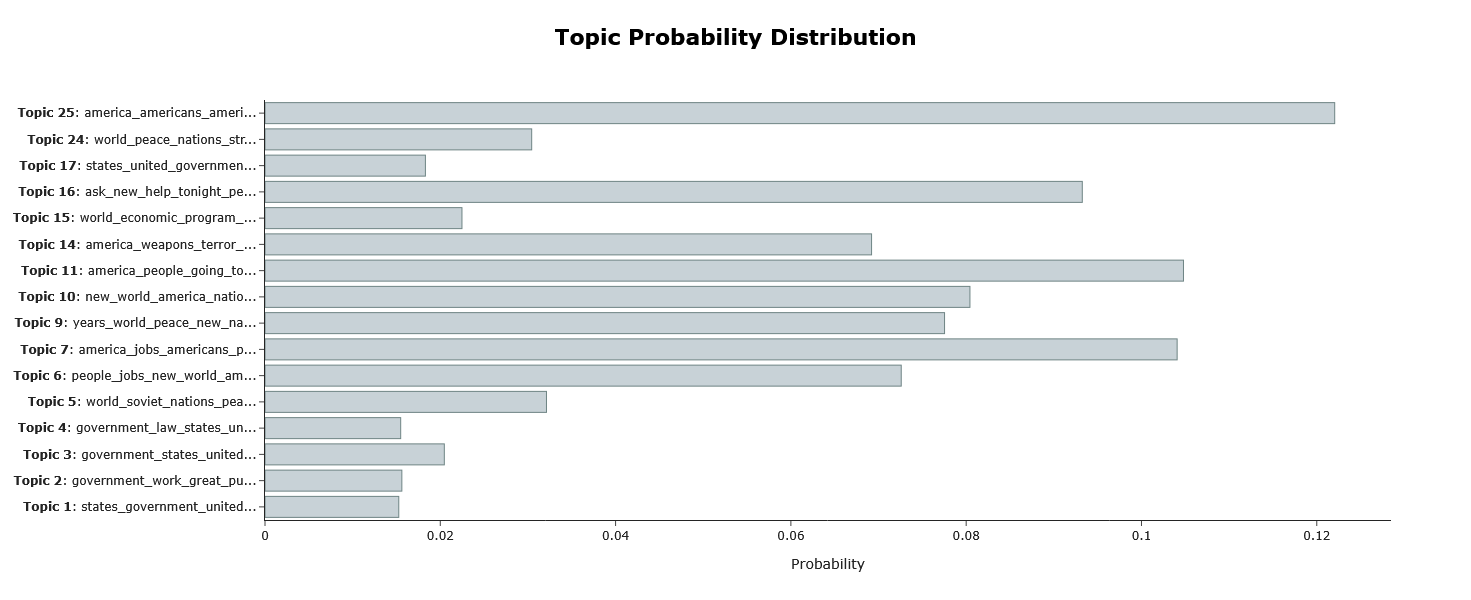

In [21]:
distributions = topic_model.approximate_distribution(docs)

first_dist = np.array(distributions[0]).flatten()

fig = topic_model.visualize_distribution(first_dist)
fig.write_html("outputs/bertopic_first_speech_distribution.html")
fig

#### Visualization of the topics

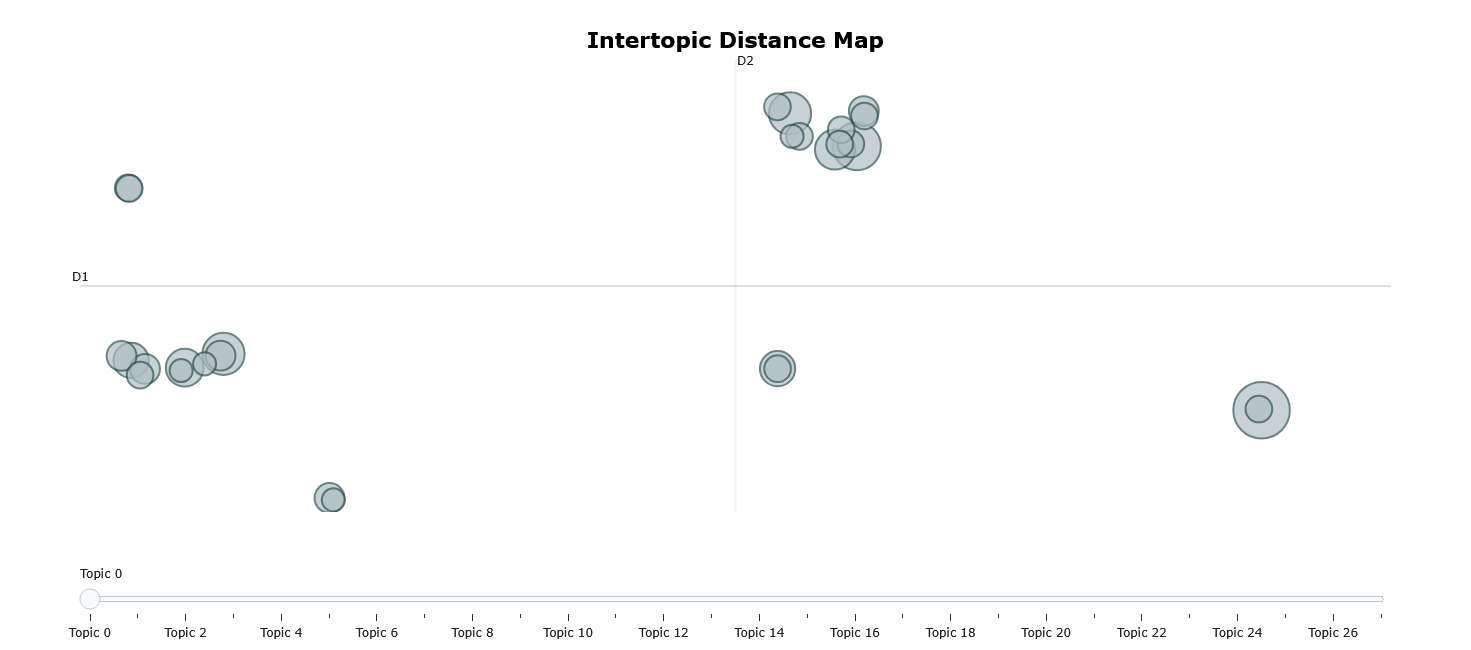

In [23]:
# run this cell to visualize the topics

fig_topic = topic_model.visualize_topics()
fig_topic.write_html("intertopic_distance_map.html")
fig_topic